<a href="https://colab.research.google.com/github/nusrarahman15/NorthStar-Analytics-Project/blob/main/northstar_r_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#  Step 1: Install R packages in Colab (run this first, takes ~2 min)
!apt-get install -y r-base libcurl4-openssl-dev libssl-dev libxml2-dev 2>/dev/null | tail -2
!pip install rpy2==3.5.16 --quiet
print('R and rpy2 installed successfully!')

r-base is already the newest version (4.6.0-3.2204.0).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
R and rpy2 installed successfully!


In [ ]:
# ── Step 2: Load rpy2 magic (enables %%R cells) ──
%load_ext rpy2.ipython
print('rpy2 loaded — you can now run R cells with %%R magic')

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython
rpy2 loaded — you can now run R cells with %%R magic


In [ ]:
# ── Step 3: Upload northstar_dataset folder ──
# Option A: Upload from your computer
import os
os.makedirs('northstar_dataset', exist_ok=True)
from google.colab import files
print('Click the upload button below and select ALL csv files from your northstar_dataset folder')
uploaded = files.upload()
for fname, data in uploaded.items():
    with open(f'northstar_dataset/{fname}', 'wb') as f:
        f.write(data)
print('Files saved to northstar_dataset/:', os.listdir('northstar_dataset'))

Click the upload button below and select ALL csv files from your northstar_dataset folder


Saving app_events.csv to app_events (2).csv
Saving complaints.csv to complaints (2).csv
Saving customers.csv to customers (2).csv
Saving data_dictionary.csv to data_dictionary (2).csv
Saving deliveries.csv to deliveries (2).csv
Saving drivers.csv to drivers (2).csv
Saving hubs.csv to hubs (2).csv
Saving incidents.csv to incidents (2).csv
Saving orders.csv to orders (2).csv
Saving README.txt to README (2).txt
Saving vehicles.csv to vehicles (2).csv
Files saved to northstar_dataset/: ['customers.csv', 'vehicles.csv', 'data_dictionary.csv', 'customers (1).csv', 'drivers (2).csv', 'orders.csv', 'orders (2).csv', 'data_dictionary (2).csv', 'hubs.csv', 'hubs (2).csv', 'hubs (1).csv', 'complaints (2).csv', 'vehicles (1).csv', 'customers (2).csv', 'vehicles (2).csv', 'app_events (2).csv', 'orders (1).csv', 'README (1).txt', 'incidents (2).csv', 'README.txt', 'incidents (1).csv', 'data_dictionary (1).csv', 'deliveries (2).csv', 'app_events.csv', 'deliveries (1).csv', 'app_events (1).csv', 'comp

## NorthStar Urban Mobility & Logistics
### SQL in R & R Analytics
**Databases and Analytics Assignment — CP6KA500**

## Part 1 - Load NorthStar Dataset into R

In [ ]:
%%R
BASE <- 'northstar_dataset/'
customers  <- read.csv(paste0(BASE,'customers.csv'),  stringsAsFactors=FALSE)
drivers    <- read.csv(paste0(BASE,'drivers.csv'),    stringsAsFactors=FALSE)
vehicles   <- read.csv(paste0(BASE,'vehicles.csv'),   stringsAsFactors=FALSE)
orders     <- read.csv(paste0(BASE,'orders.csv'),     stringsAsFactors=FALSE)
deliveries <- read.csv(paste0(BASE,'deliveries.csv'), stringsAsFactors=FALSE)
incidents  <- read.csv(paste0(BASE,'incidents.csv'),  stringsAsFactors=FALSE)
complaints <- read.csv(paste0(BASE,'complaints.csv'), stringsAsFactors=FALSE)
hubs       <- read.csv(paste0(BASE,'hubs.csv'),       stringsAsFactors=FALSE)
cat('Datasets loaded.\n')
for (nm in c('customers','drivers','vehicles','orders','deliveries','incidents','complaints','hubs')) {
  df <- get(nm)
  cat(sprintf('  %s: %d rows x %d cols\n', nm, nrow(df), ncol(df)))
}

Datasets loaded.
  customers: 650 rows x 9 cols
  drivers: 170 rows x 8 cols
  vehicles: 120 rows x 8 cols
  orders: 1250 rows x 11 cols
  deliveries: 950 rows x 13 cols
  incidents: 280 rows x 7 cols
  complaints: 320 rows x 10 cols
  hubs: 8 rows x 5 cols


In [ ]:
#Note on Zone Names: Zone name normalisation (consolidating 16 raw variants into 7 canonical zones) is performed in the Python notebook using a dictionary mapping function. The SQL queries in this notebook operate on the raw CSV data as loaded. For fully normalised zone analysis, refer to the Python and MongoDB notebook.

## Part 2 - SQL in R using sqldf

sqldf allows standard SQL queries to be run directly on R data frames.

In [ ]:
%%R
install.packages(c('sqldf','dplyr','ggplot2','tidyr','lubridate',
                    'corrplot','scales','RColorBrewer'), repos='https://cloud.r-project.org', quiet=TRUE)
library(sqldf); library(dplyr); library(ggplot2)
library(tidyr); library(lubridate); library(corrplot)
library(scales); library(RColorBrewer)
cat('All packages loaded.\n')

All packages loaded.


### SQL Query 1 - Delivery Status Summary

In [ ]:
%%R
q1 <- sqldf("SELECT delivery_status,
                    COUNT(*) AS count,
                    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM deliveries), 1) AS pct
             FROM deliveries
             GROUP BY delivery_status
             ORDER BY count DESC")
cat('=== Q1: Delivery Status Summary ===\n')
print(q1)

=== Q1: Delivery Status Summary ===
  delivery_status count  pct
1          OnTime   616 64.8
2         Delayed   202 21.3
3          Failed   132 13.9


### SQL Query 2 — Zone Delivery Performance (JOIN)

In [ ]:
%%R
q2 <- sqldf("
  SELECT o.pickup_zone,
         COUNT(*) AS total_deliveries,
         SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failed,
         ROUND(SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS failure_rate_pct,
         ROUND(AVG(o.order_value), 2) AS avg_order_value
  FROM orders o
  JOIN deliveries d ON o.order_id = d.order_id
  GROUP BY o.pickup_zone
  ORDER BY failure_rate_pct DESC
")
cat('=== Q2: Zone Delivery Performance ===\n')
print(q2)

=== Q2: Zone Delivery Performance ===
   pickup_zone total_deliveries failed failure_rate_pct avg_order_value
1    RiverSide               66     14             21.2           86.23
2      Central               55     11             20.0           71.61
3      CENTRAL               55     11             20.0           97.49
4        North               37      7             18.9           86.58
5          Ctr               64     11             17.2           93.45
6        north               52      8             15.4           93.79
7        NORTH               46      7             15.2           89.13
8         EAST               78     11             14.1           93.85
9         West               51      7             13.7           86.45
10       South               83     10             12.0           90.65
11     Airport               67      8             11.9          103.75
12        WEST               63      7             11.1           91.15
13        East            

### SQL Query 3 - Driver Performance (JOIN + HAVING)

In [ ]:
%%R
q3 <- sqldf("
  SELECT d.driver_id, dr.driver_rating, dr.employment_type, dr.base_zone,
         COUNT(*) AS total_deliveries,
         SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END) AS failures,
         ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_cust_rating
  FROM deliveries d
  JOIN drivers dr ON d.driver_id = dr.driver_id
  GROUP BY d.driver_id
  HAVING total_deliveries >= 5
  ORDER BY failures DESC
  LIMIT 10
")
cat('=== Q3: Top 10 Drivers by Failure Count ===\n')
print(q3)

=== Q3: Top 10 Drivers by Failure Count ===
   driver_id driver_rating employment_type base_zone total_deliveries failures
1       D133          3.99        Contract     South               12        4
2       D104          3.45        FullTime      WEST                7        4
3       D024          3.35        PartTime RiverSide                8        4
4       D131          4.26        FullTime     SOUTH                9        3
5       D108          4.33        FullTime     South               11        3
6       D092          4.24        FullTime      East                5        3
7       D083          4.16        FullTime     North                9        3
8       D055          5.00        FullTime   Central               10        3
9       D010          3.95        FullTime      West                7        3
10      D004          4.75        PartTime   Airport                9        3
   avg_cust_rating
1             3.42
2             3.93
3             3.44
4          

### SQL Query 4 - Complaint Analysis

In [ ]:
%%R
q4 <- sqldf("
  SELECT complaint_type,
         COUNT(*) AS total,
         ROUND(AVG(resolution_days), 1) AS avg_resolution_days,
         ROUND(AVG(compensation_amount), 2) AS avg_compensation,
         SUM(CASE WHEN severity = 'High' THEN 1 ELSE 0 END) AS high_severity_count
  FROM complaints
  GROUP BY complaint_type
  ORDER BY total DESC
")
cat('=== Q4: Complaints by Type ===\n')
print(q4)

=== Q4: Complaints by Type ===
     complaint_type total avg_resolution_days avg_compensation
1             Delay   101                 7.3            18.05
2      MissedPickup    64                 7.6            22.59
3          AppIssue    53                 8.6            19.61
4   DriverBehaviour    51                 8.2            21.15
5 SupportExperience    20                 7.5            17.13
6           Billing    16                 7.8            23.87
7            Damage    15                11.3            23.98
  high_severity_count
1                  18
2                  16
3                  13
4                  16
5                   3
6                   4
7                   7


### SQL Query 5 - Repeat Complainers (Subquery Optimisation)

In [ ]:
%%R
q5 <- sqldf("
  SELECT c.customer_id, cu.customer_type, cu.home_zone,
         c.complaint_count, cu.loyalty_score
  FROM (
    SELECT customer_id, COUNT(*) AS complaint_count
    FROM complaints
    GROUP BY customer_id
    HAVING COUNT(*) > 1
  ) c
  JOIN customers cu ON c.customer_id = cu.customer_id
  ORDER BY complaint_count DESC
  LIMIT 10
")
cat('=== Q5: Repeat Complainers (>1 complaint) ===\n')
print(q5)

=== Q5: Repeat Complainers (>1 complaint) ===
   customer_id customer_type home_zone complaint_count loyalty_score
1        C0368      Consumer     North               4          49.5
2        C0110      Consumer      EAST               3            NA
3        C0142      Consumer     SOUTH               3          47.0
4        C0172      Consumer     north               3          75.4
5        C0191      Consumer     North               3          58.9
6        C0242      Consumer      East               3          83.8
7        C0282      Consumer RiverSide               3          71.4
8        C0372      Consumer      West               3          26.2
9        C0421      Consumer   CENTRAL               3          59.0
10       C0545      Consumer     SOUTH               3          66.9


### SQL Query 6 - Vehicle Maintenance by Zone

In [ ]:
%%R
q6 <- sqldf("
  SELECT assigned_zone, vehicle_type, COUNT(*) AS total,
         SUM(CASE WHEN maintenance_status = 'InRepair' THEN 1 ELSE 0 END) AS in_repair,
         ROUND(AVG(battery_health_pct), 1) AS avg_battery_pct,
         ROUND(AVG(odometer_km), 0) AS avg_odometer_km
  FROM vehicles
  GROUP BY assigned_zone, vehicle_type
  ORDER BY in_repair DESC
")
cat('=== Q6: Vehicle Status by Zone and Type ===\n')
print(q6)

=== Q6: Vehicle Status by Zone and Type ===
   assigned_zone vehicle_type total in_repair avg_battery_pct avg_odometer_km
1      Riverside     CargoVan     3         3            68.4          119567
2        AIRPORT           EV     5         2            87.7          130037
3        AIRPORT       Hybrid     4         2            65.2          172512
4      Riverside           EV     2         2            85.1          185727
5        AIRPORT     CargoVan     1         1            78.1           89109
6        AIRPORT       Diesel     3         1            55.1           90611
7        Airport     CargoVan     1         1            78.2           67614
8        CENTRAL     CargoVan     3         1            80.4          121125
9        Central       Diesel     2         1            70.9           96861
10       Central       Hybrid     1         1            58.9           52725
11           Ctr     CargoVan     1         1            80.2           65113
12          EAST    

## Part 3 - R Analytics: Statistical Analysis & Visualisation

In [ ]:
%%R
cat('=== Order Value Summary ===\n')
print(summary(orders$order_value))
cat('\n=== Driver Rating Summary ===\n')
print(summary(drivers$driver_rating))
cat('\n=== Customer Loyalty Score ===\n')
print(summary(customers$loyalty_score))
cat(sprintf('\nSD order_value: %.2f\n', sd(orders$order_value, na.rm=TRUE)))
cat(sprintf('SD driver_rating: %.2f\n', sd(drivers$driver_rating, na.rm=TRUE)))
cat(sprintf('SD loyalty_score: %.2f\n', sd(customers$loyalty_score, na.rm=TRUE)))

=== Order Value Summary ===
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   2.04   47.91   76.53   91.05  121.10  510.06 

=== Driver Rating Summary ===
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  3.150   3.905   4.175   4.172   4.478   5.000 

=== Customer Loyalty Score ===
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
  13.10   49.00   59.60   59.69   70.45   99.00      20 

SD order_value: 60.92
SD driver_rating: 0.41
SD loyalty_score: 16.12


### Chart 1 - Delivery Status Distribution (Pie Chart)

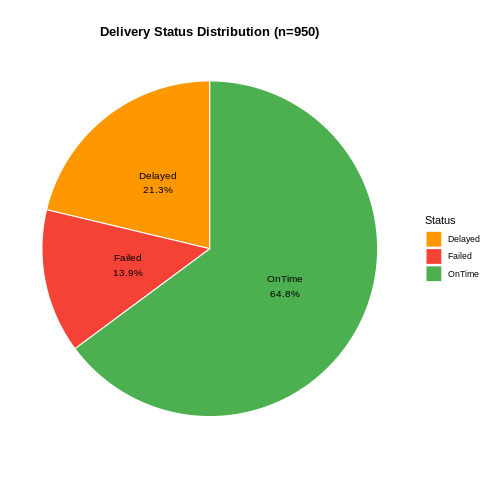

In [ ]:
%%R
del_status <- deliveries %>%
  count(delivery_status) %>%
  mutate(pct = round(n/sum(n)*100, 1),
         label = paste0(delivery_status, '\n', pct, '%'))

p1 <- ggplot(del_status, aes(x='', y=n, fill=delivery_status)) +
  geom_col(width=1, colour='white') +
  coord_polar(theta='y') +
  scale_fill_manual(values=c('OnTime'='#4caf50','Delayed'='#ff9800','Failed'='#f44336')) +
  geom_text(aes(label=label), position=position_stack(vjust=0.5), size=3.5) +
  labs(title='Delivery Status Distribution (n=950)', fill='Status') +
  theme_void() +
  theme(plot.title=element_text(hjust=0.5, face='bold', size=13))
print(p1)

### Chart 2 - Zone Failure Rates

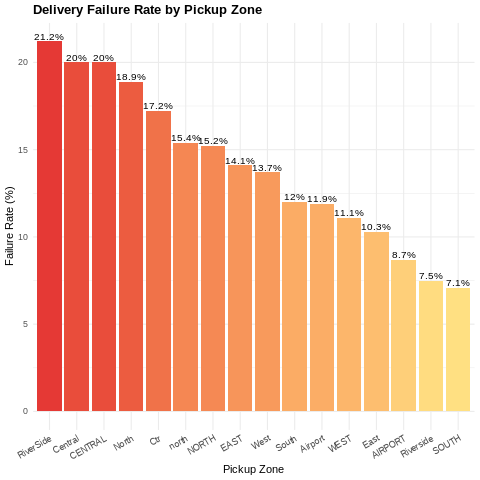

In [ ]:
%%R
zone_data <- q2 %>%
  arrange(desc(failure_rate_pct)) %>%
  mutate(pickup_zone = factor(pickup_zone, levels=pickup_zone))

p2 <- ggplot(zone_data, aes(x=pickup_zone, y=failure_rate_pct, fill=failure_rate_pct)) +
  geom_col(show.legend=FALSE) +
  geom_text(aes(label=paste0(failure_rate_pct, '%')), vjust=-0.3, size=3.5) +
  scale_fill_gradient(low='#ffe082', high='#e53935') +
  labs(title='Delivery Failure Rate by Pickup Zone',
       x='Pickup Zone', y='Failure Rate (%)') +
  theme_minimal(base_size=11) +
  theme(plot.title=element_text(face='bold', size=13),
        axis.text.x=element_text(angle=30, hjust=1))
print(p2)

### Chart 3 - Order Value by Service Type (Boxplot)

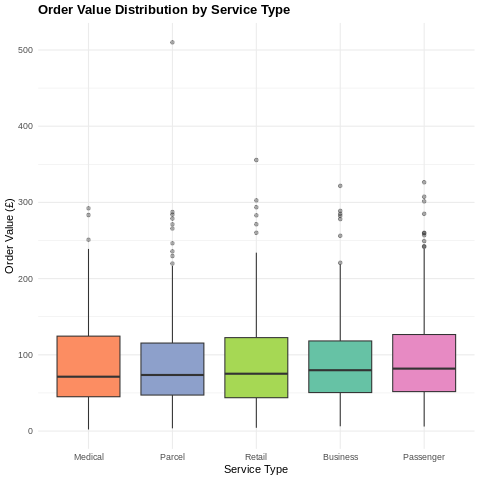

In [ ]:
%%R
p3 <- ggplot(orders, aes(x=reorder(service_type, order_value, median), y=order_value, fill=service_type)) +
  geom_boxplot(outlier.alpha=0.4, outlier.size=1.5) +
  scale_fill_brewer(palette='Set2') +
  labs(title='Order Value Distribution by Service Type',
       x='Service Type', y='Order Value (£)', fill='') +
  theme_minimal(base_size=11) +
  theme(plot.title=element_text(face='bold', size=13), legend.position='none')
print(p3)

### Correlation Analysis - Driver Metrics

=== Correlation Matrix (Driver Metrics) ===
                rating training fail_rate avg_cust_rating
rating           1.000   -0.091    -0.186           0.262
training        -0.091    1.000     0.139           0.015
fail_rate       -0.186    0.139     1.000          -0.445
avg_cust_rating  0.262    0.015    -0.445           1.000


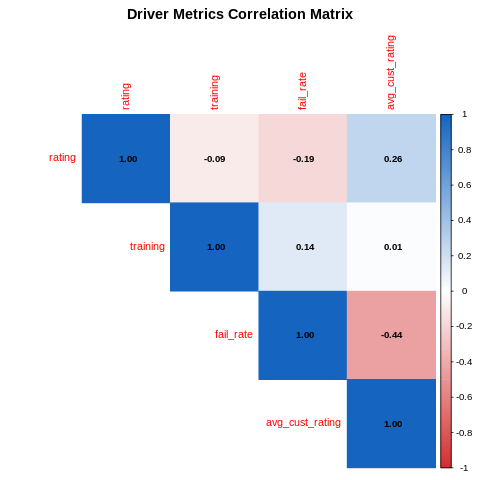

In [ ]:
%%R
drv_del <- merge(deliveries, drivers, by='driver_id', all.x=TRUE)
drv_stats <- drv_del %>%
  group_by(driver_id) %>%
  summarise(
    rating = first(driver_rating),
    training = first(training_score),
    fail_rate = mean(delivery_status == 'Failed') * 100,
    avg_cust_rating = mean(customer_rating_post_delivery, na.rm=TRUE),
    n = n(), .groups='drop'
  ) %>% filter(n >= 3)

corr_data <- drv_stats[, c('rating','training','fail_rate','avg_cust_rating')]
corr_mat  <- cor(corr_data, use='complete.obs')
cat('=== Correlation Matrix (Driver Metrics) ===\n')
print(round(corr_mat, 3))

corrplot(corr_mat, method='color', type='upper', tl.cex=0.9,
         col=colorRampPalette(c('#d32f2f','white','#1565c0'))(200),
         addCoef.col='black', number.cex=0.8,
         title='Driver Metrics Correlation Matrix', mar=c(0,0,2,0))

### Chart 4 - Driver Rating vs Failure Rate (Scatter + Regression)

`geom_smooth()` using formula = 'y ~ x'


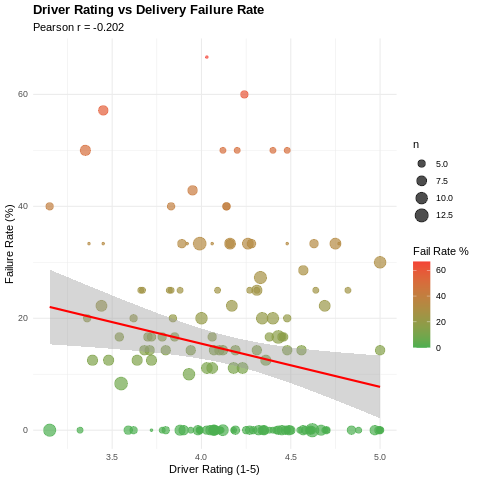

In [ ]:
%%R
p4 <- ggplot(drv_stats, aes(x=rating, y=fail_rate)) +
  geom_point(aes(colour=fail_rate, size=n), alpha=0.7) +
  geom_smooth(method='lm', se=TRUE, colour='red', linewidth=1) +
  scale_colour_gradient(low='#4caf50', high='#f44336', name='Fail Rate %') +
  labs(title='Driver Rating vs Delivery Failure Rate',
       subtitle=paste0('Pearson r = ', round(cor(drv_stats$rating, drv_stats$fail_rate, use='complete.obs'), 3)),
       x='Driver Rating (1-5)', y='Failure Rate (%)') +
  theme_minimal(base_size=11) +
  theme(plot.title=element_text(face='bold', size=13))
print(p4)

### Linear Regression - Failure Rate ~ Driver Rating + Training

In [ ]:
%%R
model <- lm(fail_rate ~ rating + training, data=drv_stats)
cat('=== Linear Regression: Failure Rate ~ Driver Rating + Training Score ===\n')
print(summary(model))
cat(sprintf('\nR-squared: %.4f\n', summary(model)$r.squared))
cat('Interpretation: A 1-unit increase in driver rating is associated with a',
    round(abs(coef(model)['rating']), 2), 'pp decrease in failure rate.\n')

=== Linear Regression: Failure Rate ~ Driver Rating + Training Score ===

Call:
lm(formula = fail_rate ~ rating + training, data = drv_stats)

Residuals:
    Min      1Q  Median      3Q     Max 
-22.838 -12.289  -4.279  10.587  49.593 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)  
(Intercept)  28.9128    16.5092   1.751   0.0821 .
rating       -6.7118     3.1530  -2.129   0.0350 *
training      0.1775     0.1180   1.504   0.1347  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 15.68 on 142 degrees of freedom
  (6 observations deleted due to missingness)
Multiple R-squared:  0.04977,	Adjusted R-squared:  0.03639 
F-statistic: 3.719 on 2 and 142 DF,  p-value: 0.02666


R-squared: 0.0498
Interpretation: A 1-unit increase in driver rating is associated with a 6.71 pp decrease in failure rate.


### Chart 5 - Complaint Types with Resolution Time

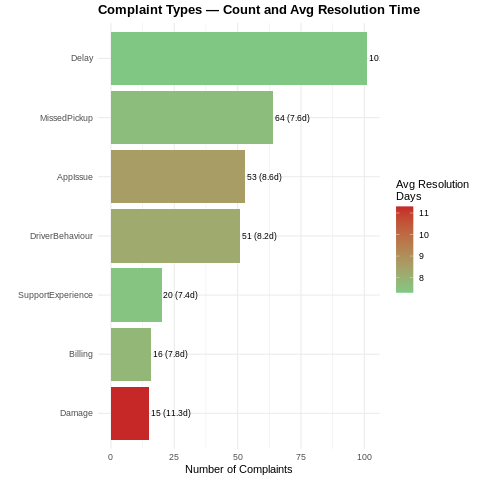

In [ ]:
%%R
comp_summary <- complaints %>%
  group_by(complaint_type) %>%
  summarise(count=n(), avg_days=round(mean(resolution_days, na.rm=TRUE), 1),
            avg_comp=round(mean(compensation_amount, na.rm=TRUE), 2), .groups='drop') %>%
  arrange(desc(count))

p5 <- ggplot(comp_summary, aes(x=reorder(complaint_type, count), y=count, fill=avg_days)) +
  geom_col() +
  geom_text(aes(label=paste0(count, ' (', avg_days, 'd)')), hjust=-0.05, size=3) +
  scale_fill_gradient(low='#81c784', high='#c62828', name='Avg Resolution\nDays') +
  coord_flip() +
  labs(title='Complaint Types — Count and Avg Resolution Time', x='', y='Number of Complaints') +
  theme_minimal(base_size=11) +
  theme(plot.title=element_text(face='bold', size=13))
print(p5)

### Chart 6 - Customer Type Distribution by Zone

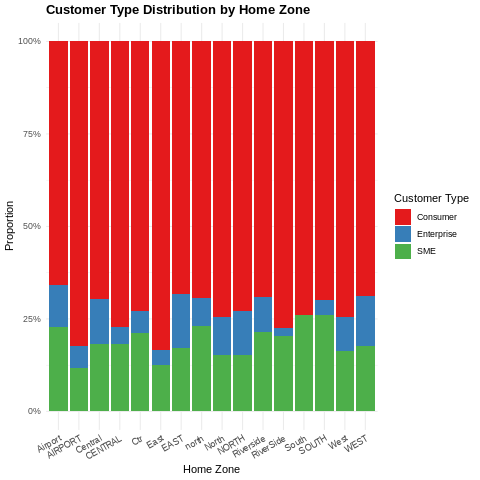

In [ ]:
%%R
cust_zone <- customers %>%
  filter(!is.na(home_zone)) %>%
  count(home_zone, customer_type)

p6 <- ggplot(cust_zone, aes(x=home_zone, y=n, fill=customer_type)) +
  geom_col(position='fill') +
  scale_y_continuous(labels=percent_format()) +
  scale_fill_brewer(palette='Set1') +
  labs(title='Customer Type Distribution by Home Zone',
       x='Home Zone', y='Proportion', fill='Customer Type') +
  theme_minimal(base_size=11) +
  theme(plot.title=element_text(face='bold', size=13),
        axis.text.x=element_text(angle=30, hjust=1))
print(p6)

### Chart 7 - Incident Types by Severity

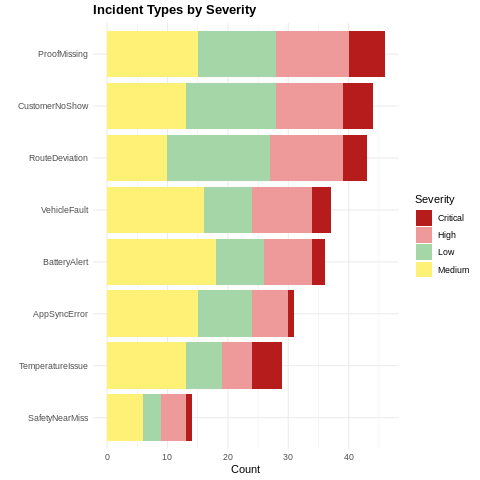

In [ ]:
%%R
inc_summary <- incidents %>%
  group_by(incident_type, severity) %>%
  summarise(count=n(), avg_resolved_hrs=round(mean(resolved_hours, na.rm=TRUE), 1), .groups='drop')

p7 <- ggplot(inc_summary, aes(x=reorder(incident_type, count, sum), y=count, fill=severity)) +
  geom_col() +
  scale_fill_manual(values=c('Low'='#a5d6a7','Medium'='#fff176','High'='#ef9a9a','Critical'='#b71c1c')) +
  coord_flip() +
  labs(title='Incident Types by Severity', x='', y='Count', fill='Severity') +
  theme_minimal(base_size=11) +
  theme(plot.title=element_text(face='bold', size=13))
print(p7)